<a href="https://colab.research.google.com/github/rchirutkar/AgenticAI/blob/main/Week5_Learner_Tools_MCP_MultiTool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learner Workbook  
## Agentic AI for Coders — Classes 4 & 5: Tools, MCP & Multi-Tool Flows  
### Live Tavily + MCP version

**Duration:** 2 sessions × 2.5 hours  
**Format:** Concepts + runnable Python + live search + quizzes + capstones  
**Important:** This notebook uses **real Tavily Search** and does not include fake search outputs. Tavily can run in rate-limited keyless mode; `TAVILY_API_KEY` is optional for higher limits.

## What you will build
1. A tool schema and validation layer.
2. A live Tavily search tool.
3. Sequential vs parallel search measurement.
4. A news aggregator that ranks live results with a Reviewer LLM.
5. A Tavily MCP tool-discovery demo.
6. An enhanced RAG/web fallback agent skeleton.

<div style="text-align:center">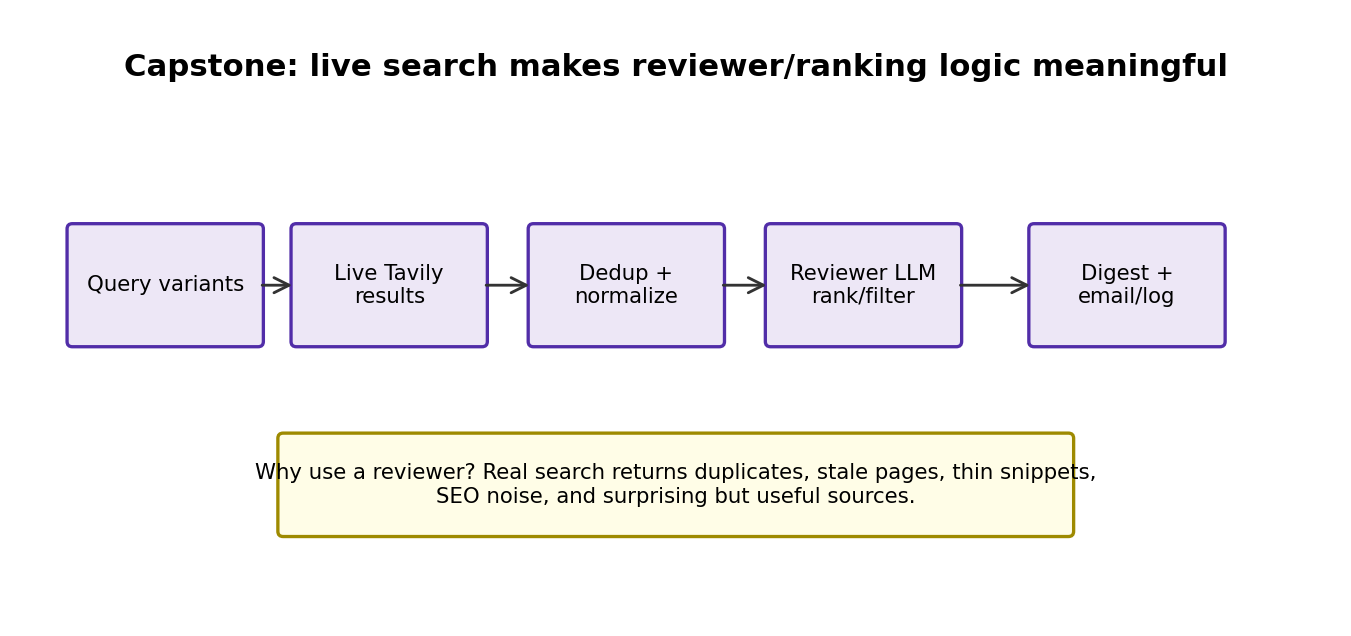</div>

## Before you start

This workbook is designed for **Google Colab first**.

1. Run the install cell.
2. In Colab, open the **Secrets** panel (key icon).
3. Add either `GROQ_API_KEY` or `OPENROUTER_API_KEY` and enable notebook access.
4. `TAVILY_API_KEY` is optional: Tavily Search and the remote MCP server can run in keyless mode for light classroom use.

Do not paste secrets directly into code cells, screenshots, or shared notebooks.

In [ ]:
# Run once in a fresh Google Colab or Jupyter environment.
%pip install -q httpx pydantic ipywidgets matplotlib pandas mcp openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.6/222.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 37.7 MB/s eta 0:00:00


In [ ]:
# Core setup for both sessions
import os, sys, json, time, asyncio, math, re, sqlite3, uuid, statistics
from dataclasses import dataclass
from collections import deque, Counter, defaultdict
from typing import Any, Dict, List, Optional, Tuple
from urllib.parse import urlparse, urlunparse

print("Python:", sys.version.split()[0])
print("Colab-first setup ready. Tavily can run keylessly; Groq/OpenRouter needs a free API key.")

Python: 3.12.13
Colab-first setup ready. Tavily can run keylessly; Groq/OpenRouter needs a free API key.


In [ ]:
import os
from typing import Optional


def load_secret(name: str, *, required: bool = False) -> Optional[str]:
    """Load a secret from the local environment or Google Colab Secrets."""
    value = os.getenv(name)
    if not value:
        try:
            from google.colab import userdata  # type: ignore
            value = userdata.get(name)
        except Exception:
            value = None
    if value:
        os.environ[name] = value
    if required and not value:
        raise RuntimeError(
            f"Missing {name}. In Colab, open the key icon (Secrets), add {name}, "
            "and enable notebook access. Locally, set it as an environment variable."
        )
    return value


LLM_PROVIDER = os.getenv("LLM_PROVIDER", "groq").strip().lower()
if LLM_PROVIDER not in {"groq", "openrouter"}:
    raise ValueError("LLM_PROVIDER must be 'groq' or 'openrouter'.")


def get_llm_client_and_model():
    """Return an OpenAI-compatible client configured for Groq or OpenRouter."""
    from openai import OpenAI

    if LLM_PROVIDER == "groq":
        api_key = load_secret("GROQ_API_KEY", required=True)
        model = os.getenv("GROQ_MODEL", "openai/gpt-oss-20b")
        client = OpenAI(base_url="https://api.groq.com/openai/v1", api_key=api_key)
        return client, model

    api_key = load_secret("OPENROUTER_API_KEY", required=True)
    model = os.getenv("OPENROUTER_MODEL", "openrouter/free")
    client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=api_key,
        default_headers={"X-OpenRouter-Title": "Agentic AI Learning Lab"},
    )
    return client, model


configured_key = "GROQ_API_KEY" if LLM_PROVIDER == "groq" else "OPENROUTER_API_KEY"
print(f"LLM provider: {LLM_PROVIDER}")
print(f"Model override: {os.getenv('GROQ_MODEL') or os.getenv('OPENROUTER_MODEL') or 'not set; notebook default will be used'}")
print(f"{configured_key} available:", bool(load_secret(configured_key)))

LLM provider: groq
Model override: not set; notebook default will be used
GROQ_API_KEY available: False


In [ ]:
# Interactive quiz helper
# Works with ipywidgets when available; otherwise prints questions and answer choices.

try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown, clear_output
    _WIDGETS_AVAILABLE = True
except Exception:
    _WIDGETS_AVAILABLE = False
    print("ipywidgets is not available. Quizzes will print as text.")

def run_quiz(questions, title="Interactive quiz", show_correct_after_submit=True):
    """Render a small MCQ quiz. Each item: {question, options, answer, explanation}."""
    if not _WIDGETS_AVAILABLE:
        print("\n" + title)
        for i, q in enumerate(questions, 1):
            print(f"\nQ{i}. {q['question']}")
            for j, opt in enumerate(q["options"], 1):
                print(f"  {j}. {opt}")
        print("\nAsk the facilitator for the answer key or inspect explanations after discussion.")
        return

    display(Markdown(f"### {title}"))
    rows = []
    radios = []
    for i, q in enumerate(questions, 1):
        display(Markdown(f"**Q{i}. {q['question']}**"))
        radio = widgets.RadioButtons(options=q["options"], description="", disabled=False)
        radios.append((radio, q))
        display(radio)

    out = widgets.Output()
    btn = widgets.Button(description="Submit", button_style="primary")
    def _on_click(_):
        with out:
            clear_output()
            score = 0
            for i, (radio, q) in enumerate(radios, 1):
                selected = radio.value
                correct = q["answer"]
                ok = selected == correct
                score += int(ok)
                status = "✅" if ok else "❌"
                print(f"Q{i}: {status} Your answer: {selected}")
                if show_correct_after_submit:
                    print(f"   Correct: {correct}")
                    print(f"   Why: {q.get('explanation','')}")
            print(f"\nScore: {score}/{len(radios)}")
    btn.on_click(_on_click)
    display(btn, out)

# Class 1 — Agent Tools: Concepts, Calling & Composition  
**Session duration:** 2.5 hours

## Learning objectives
By the end of Class 1, you should be able to:
- Explain what tools are in agentic AI.
- Define a tool using schema, description, and input constraints.
- Validate tool arguments before execution.
- Run a real Tavily search from Python.
- Compare sequential vs parallel live API calls.
- Build a live search-based news aggregator with reviewer/ranking logic.

<div style="text-align:center">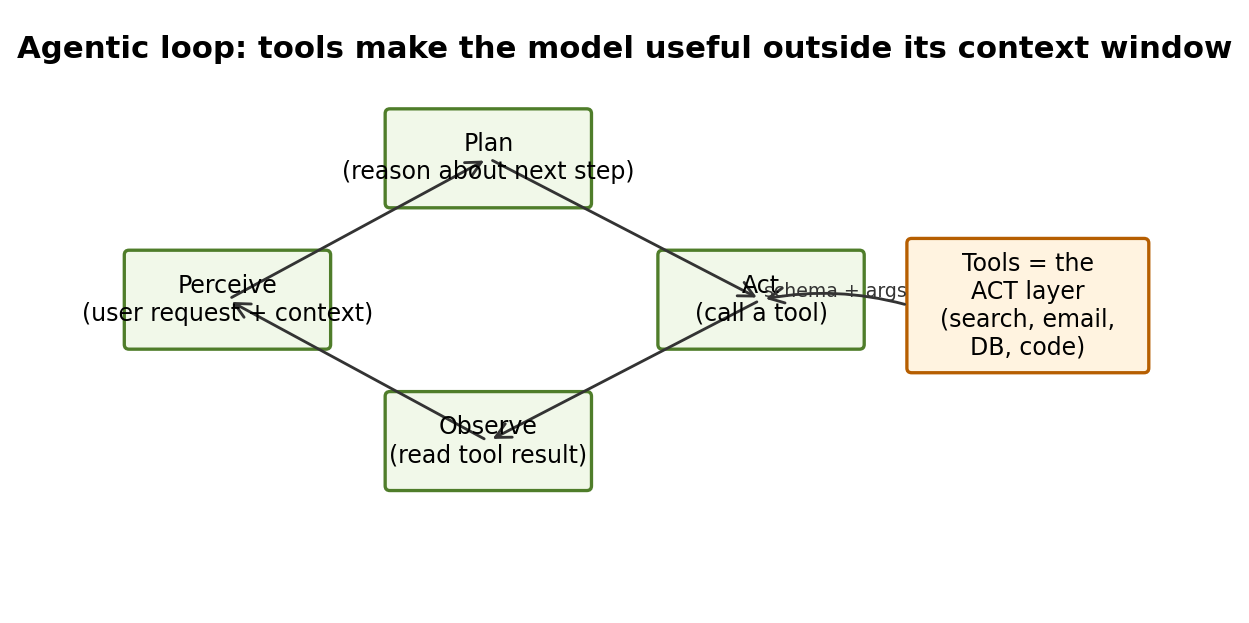</div>

## 1. What are tools?

A tool lets an agent **do something outside the model’s context window**.

Examples:
- Search the web.
- Query a database.
- Send an email.
- Run code.
- Extract a webpage.
- Ask a reviewer LLM to rank results.

The LLM does not run the tool itself. It requests the tool call, and your application executes it.

## 2. Tool schema = contract

<div style="text-align:center">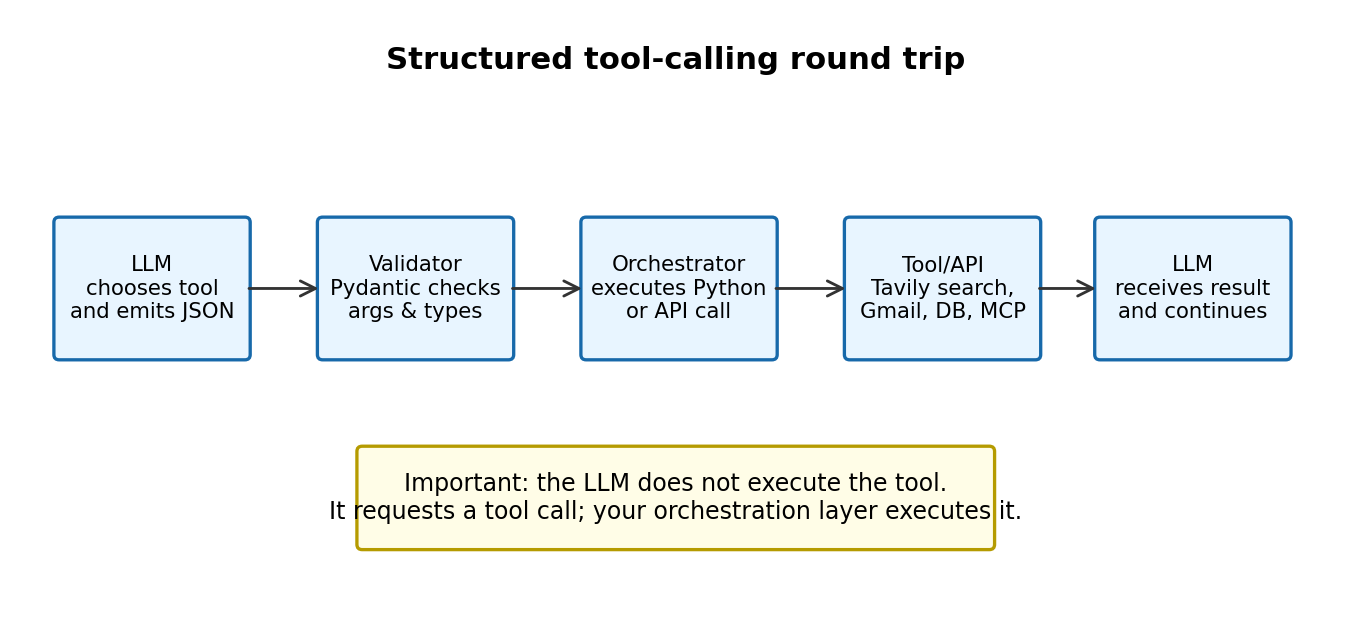</div>

A tool definition needs:
- **Name**
- **Description**
- **Input schema**
- **Implementation**

In [ ]:
from pydantic import BaseModel, Field, ValidationError
from typing import Literal

class TavilySearchArgs(BaseModel):
    query: str = Field(..., min_length=3, description="Search query to run.")
    topic: Literal["general", "news", "finance"] = "general"
    max_results: int = Field(5, ge=1, le=20)
    search_depth: Literal["basic", "advanced"] = "basic"

print("JSON schema generated from Pydantic:")
print(json.dumps(TavilySearchArgs.model_json_schema(), indent=2))

JSON schema generated from Pydantic:
{
  "properties": {
    "query": {
      "description": "Search query to run.",
      "minLength": 3,
      "title": "Query",
      "type": "string"
    },
    "topic": {
      "default": "general",
      "enum": [
        "general",
        "news",
        "finance"
      ],
      "title": "Topic",
      "type": "string"
    },
    "max_results": {
      "default": 5,
      "maximum": 20,
      "minimum": 1,
      "title": "Max Results",
      "type": "integer"
    },
    "search_depth": {
      "default": "basic",
      "enum": [
        "basic",
        "advanced"
      ],
      "title": "Search Depth",
      "type": "string"
    }
  },
  "required": [
    "query"
  ],
  "title": "TavilySearchArgs",
  "type": "object"
}


### Try it
In the next cell, change `max_results` to a valid number and then to an invalid number. Observe what Pydantic catches.

In [ ]:
candidate_args = {
    "query": "AI coding agents news",
    "topic": "news",
    "max_results": 100,  # Try changing this to 5
    "search_depth": "basic",
}

try:
    args = TavilySearchArgs(**candidate_args)
    print("Valid arguments:", args)
except ValidationError as e:
    print("Validation error:")
    print(e)

Validation error:
1 validation error for TavilySearchArgs
max_results
  Input should be less than or equal to 20 [type=less_than_equal, input_value=100, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/less_than_equal


## 3. Live Tavily Search

The next cell defines helpers for real Tavily API calls.  
If `TAVILY_API_KEY` is not set, the live cells use Tavily keyless mode. Rate limits still apply, so keep classroom requests small.

In [ ]:
import httpx
from urllib.parse import urlparse

TAVILY_SEARCH_URL = "https://api.tavily.com/search"


def tavily_headers() -> dict[str, str]:
    """Use a free Tavily API key when available; otherwise use keyless access."""
    api_key = load_secret("TAVILY_API_KEY")
    headers = {"Content-Type": "application/json"}
    if api_key:
        headers["Authorization"] = f"Bearer {api_key}"
    else:
        headers["X-Tavily-Access-Mode"] = "keyless"
    return headers


def tavily_search_live(
    query: str,
    *,
    topic: str = "general",
    max_results: int = 5,
    search_depth: str = "basic",
    time_range: Optional[str] = None,
    include_answer: bool = True,
    include_raw_content: bool = False,
    include_domains: Optional[List[str]] = None,
    exclude_domains: Optional[List[str]] = None,
    timeout: float = 30.0,
) -> Dict[str, Any]:
    """Run a live Tavily search using keyed or keyless access."""
    payload: Dict[str, Any] = {
        "query": query,
        "topic": topic,
        "max_results": max_results,
        "search_depth": search_depth,
        "include_answer": include_answer,
        "include_raw_content": include_raw_content,
    }
    if time_range:
        payload["time_range"] = time_range
    if include_domains:
        payload["include_domains"] = include_domains
    if exclude_domains:
        payload["exclude_domains"] = exclude_domains

    t0 = time.perf_counter()
    with httpx.Client(timeout=timeout) as client:
        response = client.post(TAVILY_SEARCH_URL, headers=tavily_headers(), json=payload)
        response.raise_for_status()
        data = response.json()
    data["_local_wall_clock_s"] = round(time.perf_counter() - t0, 3)
    data["_access_mode"] = "api_key" if load_secret("TAVILY_API_KEY") else "keyless"
    return data


def summarize_tavily_response(response: Dict[str, Any], max_rows: int = 5) -> List[Dict[str, Any]]:
    rows = []
    for i, result in enumerate(response.get("results", [])[:max_rows], 1):
        rows.append({
            "rank": i,
            "title": result.get("title"),
            "domain": urlparse(result.get("url", "")).netloc,
            "score": round(float(result.get("score", 0)), 3) if result.get("score") is not None else None,
            "published_date": result.get("published_date"),
            "url": result.get("url"),
            "snippet": (result.get("content") or "")[:260].replace("\n", " "),
        })
    return rows


def print_search_table(rows: List[Dict[str, Any]]):
    for row in rows:
        print(f"{row['rank']}. {row['title']}")
        print(f"   domain={row['domain']} score={row['score']} published={row['published_date']}")
        print(f"   {row['snippet']}")
        print(f"   {row['url']}\n")

### Run one live search

Change the query to something relevant to your class or domain. Watch for:
- Result quality.
- Duplicate/near-duplicate results.
- Search score.
- Published date when `topic="news"`.
- Tavily `response_time`.
- Local wall-clock latency.

In [ ]:
# Class 1 live demo: one actual Tavily search
# Change the query to something topical for the cohort.

query = "latest agentic AI tool use for software developers"
response = tavily_search_live(
    query,
    topic="news",
    time_range="week",
    max_results=5,
    search_depth="basic",
    include_answer=True,
)

print("Query:", response.get("query"))
print("Tavily response_time:", response.get("response_time"))
print("Local wall-clock seconds:", response.get("_local_wall_clock_s"))
print("Request ID:", response.get("request_id"))
print("Access mode:", response.get("_access_mode"))
print("\nTavily answer:\n", response.get("answer"))
print("\nTop results:\n")
print_search_table(summarize_tavily_response(response))

Query: latest agentic AI tool use for software developers
Tavily response_time: 3.18
Local wall-clock seconds: 4.443
Request ID: cf1a1b9b-4645-4b68-a1b3-97b32b20eb1c
Access mode: keyless

Tavily answer:
 Recent agentic AI tools for software developers include Meta's Muse Spark 1.1, which is designed for agentic tasks like coding and multimodal understanding, and OpenAI's GPT-5.6 Sol, which is 54% more token efficient on agentic coding tasks. Anthropic's Claude Cowork agent has also been updated to be available on mobile and web platforms, enhancing its utility for developers and other professionals.

Top results:

1. Meta Introduces a Big New AI Model for the Agentic Age - CNET
   domain=www.cnet.com score=0.552 published=Thu, 09 Jul 2026 20:58:00 GMT
   # Meta Introduces a Big New AI Model for the Agentic Age. A public preview of Muse Spark 1.1 is now available to developers. Meta on Thursday announced the next version") of its multimodal Spark AI model, Muse Spark 1.1, calling it a s

### Reflection: inspect your live search

Answer in your own words:

1. Which result is most relevant?
2. Which result is least relevant?
3. Did any result surprise you?
4. What should a reviewer LLM check before allowing these results into a final digest?

In [ ]:
# Write your observations here as a Python dictionary.
search_observations = {
    "most_relevant_result": "",
    "least_relevant_result": "",
    "surprising_result": "",
    "reviewer_should_check": "",
}
search_observations

{'most_relevant_result': '',
 'least_relevant_result': '',
 'surprising_result': '',
 'reviewer_should_check': ''}

## 4. Sequential vs parallel live API calls

<div style="text-align:center">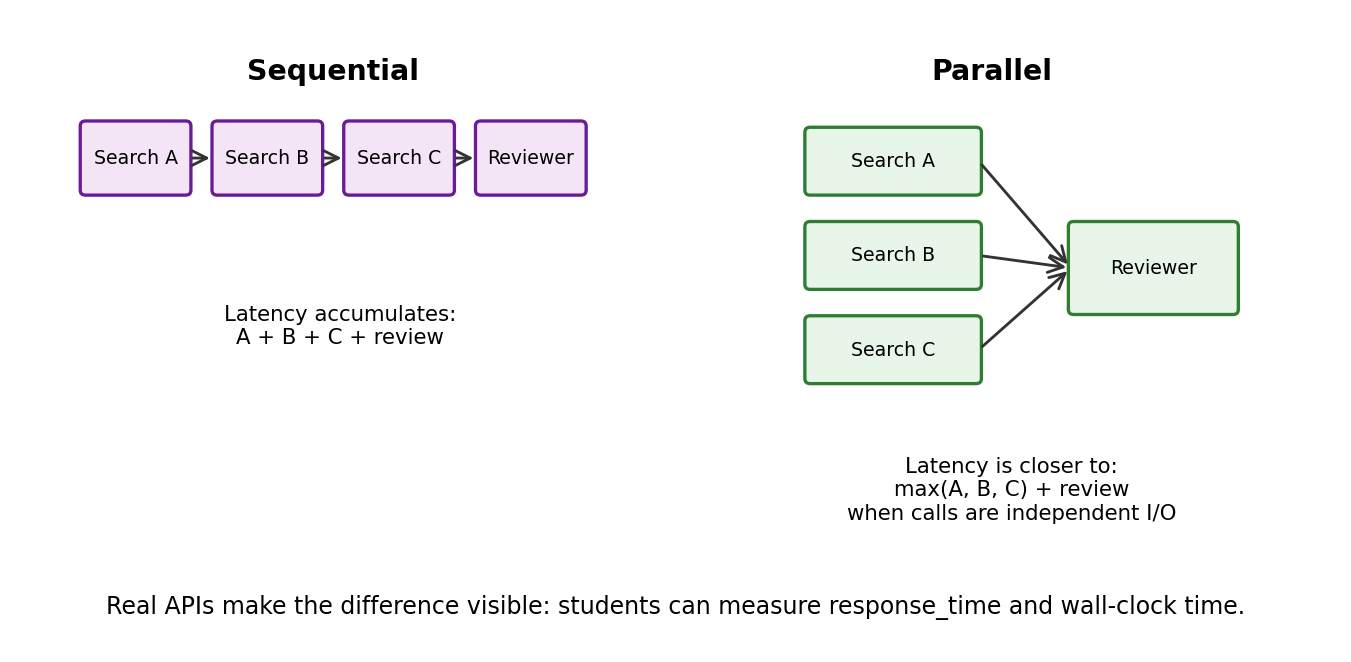</div>

Sequential calls wait one after another. Parallel calls let independent I/O-bound searches run concurrently.

In [ ]:
# Visualize latency from repeated live searches.
# Keep max_results small to conserve credits.

queries = [
    "AI coding agents recent news",
    "Model Context Protocol tools search extract crawl",
    "Tavily search API agentic workflows",
]

latency_records = []
for q in queries:
    try:
        r = tavily_search_live(q, topic="general", max_results=3, search_depth="basic", include_answer=False)
        latency_records.append({
            "query": q,
            "tavily_response_time": r.get("response_time"),
            "local_wall_clock_s": r.get("_local_wall_clock_s"),
            "result_count": len(r.get("results", [])),
            "request_id": r.get("request_id"),
        })
    except Exception as e:
        latency_records.append({"query": q, "error": type(e).__name__, "message": str(e)})

latency_records

[{'query': 'AI coding agents recent news',
  'tavily_response_time': 0.47,
  'local_wall_clock_s': 1.434,
  'result_count': 3,
  'request_id': 'd23b0c2e-feb8-4f9c-a13d-293f72f3120d'},
 {'query': 'Model Context Protocol tools search extract crawl',
  'tavily_response_time': 0.59,
  'local_wall_clock_s': 1.627,
  'result_count': 3,
  'request_id': '3a88ac85-3617-4462-a57f-d5a7a60c184f'},
 {'query': 'Tavily search API agentic workflows',
  'tavily_response_time': 0.59,
  'local_wall_clock_s': 1.679,
  'result_count': 3,
  'request_id': '01314093-da69-4789-9cb1-47c4d4750aa4'}]

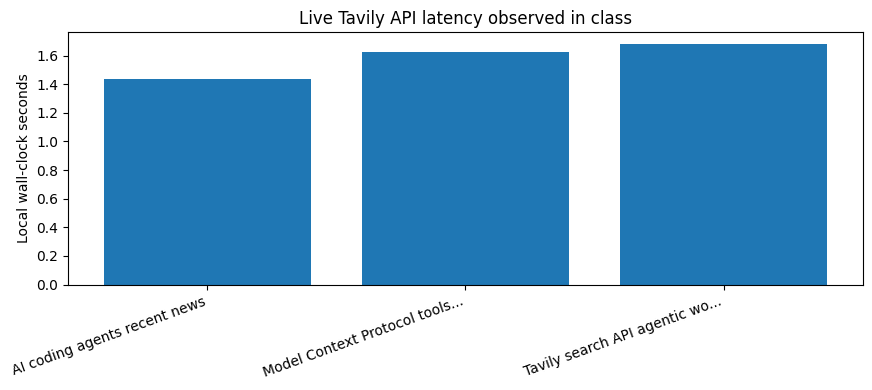

In [ ]:
# Plot the measured local wall-clock time for live Tavily calls.

import matplotlib.pyplot as plt

successful = [r for r in latency_records if "local_wall_clock_s" in r]
if not successful:
    print("No successful calls to plot. Check API key, network, and rate limits.")
else:
    labels = [r["query"][:28] + ("..." if len(r["query"]) > 28 else "") for r in successful]
    values = [r["local_wall_clock_s"] for r in successful]
    plt.figure(figsize=(9, 4))
    plt.bar(labels, values)
    plt.ylabel("Local wall-clock seconds")
    plt.title("Live Tavily API latency observed in class")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

In [ ]:
# Sequential versus parallel live Tavily searches using the same keyed/keyless endpoint.

async def tavily_search_async(query: str, *, max_results: int = 3, topic: str = "general") -> Dict[str, Any]:
    payload = {
        "query": query,
        "topic": topic,
        "max_results": max_results,
        "search_depth": "basic",
        "include_answer": False,
        "include_raw_content": False,
    }
    t0 = time.perf_counter()
    async with httpx.AsyncClient(timeout=30.0) as client:
        response = await client.post(TAVILY_SEARCH_URL, headers=tavily_headers(), json=payload)
        response.raise_for_status()
        data = response.json()
    data["_local_wall_clock_s"] = round(time.perf_counter() - t0, 3)
    return data


async def run_sequential(queries: List[str]):
    t0 = time.perf_counter()
    results = []
    for query in queries:
        results.append(await tavily_search_async(query, max_results=3))
    return results, round(time.perf_counter() - t0, 3)


async def run_parallel(queries: List[str]):
    t0 = time.perf_counter()
    results = await asyncio.gather(
        *[tavily_search_async(query, max_results=3) for query in queries],
        return_exceptions=True,
    )
    return results, round(time.perf_counter() - t0, 3)


queries = [
    "latest AI coding agents and developer workflows",
    "Model Context Protocol remote tool discovery",
    "Tavily agent web search examples",
]

seq_results, seq_s = await run_sequential(queries)
par_results, par_s = await run_parallel(queries)

print(f"Sequential wall-clock: {seq_s}s")
print(f"Parallel wall-clock:   {par_s}s")
print(f"Speedup: {round(seq_s / par_s, 2) if par_s else 'n/a'}x")

for label, results in [("sequential", seq_results), ("parallel", par_results)]:
    print("\n", label.upper())
    for item in results:
        if isinstance(item, Exception):
            print("ERROR:", type(item).__name__, item)
        else:
            print(item.get("query"), "->", len(item.get("results", [])), "results,", item.get("_local_wall_clock_s"), "s")

Sequential wall-clock: 6.296s
Parallel wall-clock:   2.292s
Speedup: 2.75x

 SEQUENTIAL
latest AI coding agents and developer workflows -> 3 results, 1.947 s
Model Context Protocol remote tool discovery -> 3 results, 2.633 s
Tavily agent web search examples -> 3 results, 1.716 s

 PARALLEL
latest AI coding agents and developer workflows -> 3 results, 2.292 s
Model Context Protocol remote tool discovery -> 3 results, 1.542 s
Tavily agent web search examples -> 3 results, 0.882 s


### Reflection: latency

Did the parallel version improve wall-clock time? Why or why not?

In [ ]:
latency_reflection = """
Write your answer here.
"""
print(latency_reflection)


Write your answer here.



## 5. Capstone 1 — Live news aggregator

You will build a small pipeline:

**topic/date/location → query variants → live Tavily searches → deduplicate → reviewer LLM → digest**

The reviewer matters because real results are messy.

In [ ]:
# Capstone helpers: query generation, deduplication, and reviewer packet creation

def build_news_queries(topic: str, location: str = "", date_hint: str = "") -> List[str]:
    base = topic.strip()
    loc = f" {location.strip()}" if location.strip() else ""
    date = f" {date_hint.strip()}" if date_hint.strip() else ""
    return [
        f"{base}{loc}{date} latest news",
        f"{base}{loc}{date} analysis",
        f"{base}{loc}{date} official announcement",
        f"{base}{loc}{date} industry impact",
    ]

def normalize_url(url: str) -> str:
    p = urlparse(url or "")
    return urlunparse((p.scheme.lower(), p.netloc.lower(), p.path.rstrip("/"), "", "", ""))

def normalize_title(title: str) -> str:
    title = (title or "").lower()
    title = re.sub(r"[^a-z0-9 ]+", " ", title)
    title = re.sub(r"\s+", " ", title).strip()
    return title

def deduplicate_results(search_responses: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    seen = set()
    merged = []
    for response in search_responses:
        query = response.get("query")
        for r in response.get("results", []):
            url_key = normalize_url(r.get("url"))
            title_key = normalize_title(r.get("title"))
            key = url_key or title_key
            if not key or key in seen:
                continue
            seen.add(key)
            item = {
                "source_query": query,
                "title": r.get("title"),
                "url": r.get("url"),
                "domain": urlparse(r.get("url", "")).netloc,
                "content": r.get("content"),
                "score": r.get("score"),
                "published_date": r.get("published_date"),
            }
            merged.append(item)
    merged.sort(key=lambda x: (x.get("score") or 0), reverse=True)
    return merged

def make_reviewer_packet(items: List[Dict[str, Any]], max_items: int = 12) -> str:
    lines = []
    for i, item in enumerate(items[:max_items], 1):
        lines.append(
            f"[{i}] {item.get('title')}\n"
            f"URL: {item.get('url')}\n"
            f"Domain: {item.get('domain')}\n"
            f"Published: {item.get('published_date')}\n"
            f"Search score: {item.get('score')}\n"
            f"Snippet: {(item.get('content') or '')[:700]}\n"
        )
    return "\n".join(lines)

In [ ]:
# Capstone Part 1: live Tavily search fan-out

topic = "AI coding agents for software development"
location = "India"
date_hint = "this month"

queries = build_news_queries(topic, location, date_hint)
print("Query variants:")
for q in queries:
    print("-", q)

search_responses = []
for q in queries:
    r = tavily_search_live(q, topic="news", time_range="month", max_results=5, search_depth="basic", include_answer=False)
    print(f"{q} -> {len(r.get('results', []))} results, Tavily response_time={r.get('response_time')}, local={r.get('_local_wall_clock_s')}s")
    search_responses.append(r)

items = deduplicate_results(search_responses)
print(f"\nMerged unique results: {len(items)}")
print_search_table([
    {
        "rank": i+1,
        "title": item["title"],
        "domain": item["domain"],
        "score": round(float(item["score"] or 0), 3),
        "published_date": item.get("published_date"),
        "url": item["url"],
        "snippet": (item.get("content") or "")[:260],
    }
    for i, item in enumerate(items[:8])
])

Query variants:
- AI coding agents for software development India this month latest news
- AI coding agents for software development India this month analysis
- AI coding agents for software development India this month official announcement
- AI coding agents for software development India this month industry impact
AI coding agents for software development India this month latest news -> 5 results, Tavily response_time=0.41, local=1.267s
AI coding agents for software development India this month analysis -> 5 results, Tavily response_time=0.5, local=1.345s
AI coding agents for software development India this month official announcement -> 5 results, Tavily response_time=0.38, local=1.213s
AI coding agents for software development India this month industry impact -> 5 results, Tavily response_time=0.3, local=1.138s

Merged unique results: 9
1. AI hiring outpaces overall IT recruitment in India, report shows - Reuters
   domain=www.reuters.com score=0.778 published=Fri, 03 Jul 2026 12:

### Inspect the merged results

Before using an LLM reviewer, manually label the first five results:
- `keep`
- `maybe`
- `reject`

Give one reason for each.

In [ ]:
manual_labels = [
    {"rank": 1, "label": "", "reason": ""},
    {"rank": 2, "label": "", "reason": ""},
    {"rank": 3, "label": "", "reason": ""},
    {"rank": 4, "label": "", "reason": ""},
    {"rank": 5, "label": "", "reason": ""},
]
manual_labels

[{'rank': 1, 'label': '', 'reason': ''},
 {'rank': 2, 'label': '', 'reason': ''},
 {'rank': 3, 'label': '', 'reason': ''},
 {'rank': 4, 'label': '', 'reason': ''},
 {'rank': 5, 'label': '', 'reason': ''}]

## 6. Reviewer LLM over live search results

The reviewer should:
- Use only the numbered live results.
- Prefer relevant, recent, source-backed items.
- Reject duplicates and weak SEO pages.
- Identify missing information.
- Create digest bullets only from selected sources.

This cell uses Groq by default or OpenRouter as an alternative. Store the selected key in Colab Secrets.

In [ ]:
# Reviewer LLM: Groq by default, with OpenRouter as an alternative.
# Both use the same OpenAI-compatible client interface.

def review_with_llm(items: List[Dict[str, Any]], topic: str, max_items: int = 12) -> str:
    client, reviewer_model = get_llm_client_and_model()
    packet = make_reviewer_packet(items, max_items=max_items)
    prompt = f"""
You are the reviewer LLM for a news aggregation agent.

Goal: Rank live Tavily search results for a concise instructor-ready digest.

Topic: {topic}

Rules:
1. Use only the numbered search results below.
2. Prefer relevant, recent, specific, primary or high-quality sources.
3. Penalize duplicates, vague SEO pages, stale items, and snippets that do not support the topic.
4. Return:
   - top_5: numbered result IDs with one-line rationale each
   - reject_or_low_confidence: result IDs with reasons
   - digest_bullets: 5 concise bullets synthesized only from selected results
   - missing_information: what additional search would improve confidence

Live search results:
{packet}
"""
    response = client.chat.completions.create(
        model=reviewer_model,
        messages=[
            {"role": "system", "content": "Use only supplied evidence. Do not invent sources."},
            {"role": "user", "content": prompt},
        ],
        temperature=0.2,
    )
    return response.choices[0].message.content or ""


review = review_with_llm(items, topic)
print(review)

In [ ]:
# Capstone Part 3: format a digest from reviewer output + selected links.
# You can paste `review` into the body or parse it further if you requested JSON from the reviewer.

def format_email_digest(topic: str, review_text: str, selected_items: List[Dict[str, Any]]) -> str:
    links = "\n".join([f"- {x.get('title')} ({x.get('domain')}): {x.get('url')}" for x in selected_items[:5]])
    return f"""Subject: Live AI News Digest — {topic}

Hello,

Here is the latest digest generated from live Tavily search results and reviewed by an LLM.

Reviewer summary:
{review_text}

Top source links:
{links}

Operational notes:
- Sources came from live Tavily API calls.
- Search latency and request IDs should be retained in the run log.
- Reviewer LLM was instructed to use only numbered sources.

Regards,
News Aggregator Agent
"""

digest_body = format_email_digest(topic, review, items)
print(digest_body[:2500])

Subject: Live AI News Digest — AI coding agents for software development

Hello,

Here is the latest digest generated from live Tavily search results and reviewed by an LLM.

Reviewer summary:


Top source links:
- AI hiring outpaces overall IT recruitment in India, report shows - Reuters (www.reuters.com): https://www.reuters.com/world/india/ai-hiring-outpaces-overall-it-recruitment-india-report-shows-2026-07-03/
- MoEngage Sees the Future of Marketing in Millions of AI Agents - Zamin.uz (zamin.uz): https://zamin.uz/en/technology/208825-moengage-sees-the-future-of-marketing-in-millions-of-ai-agents.html
- Industries Expand Hiring for AI Coding Roles Amid Widespread Adoption - Hotel News Resource (www.hotelnewsresource.com): https://www.hotelnewsresource.com/article141897.html
- India’s MoEngage bets that the future of marketing is millions of AI agents - TechCrunch (techcrunch.com): https://techcrunch.com/2026/06/23/indias-moengage-bets-marketings-future-on-millions-of-ai-agents/
- Ne

## 7. Log tool calls

Production agents need logs. Log enough to reproduce and debug failures, but avoid sensitive data.

In [ ]:
# Observability: SQLite log for live tool calls and review steps

db_path = "agent_tool_runs.sqlite"
conn = sqlite3.connect(db_path)
conn.execute("""
CREATE TABLE IF NOT EXISTS tool_runs (
    run_id TEXT,
    step TEXT,
    tool_name TEXT,
    query TEXT,
    latency_s REAL,
    result_count INTEGER,
    success INTEGER,
    request_id TEXT,
    error TEXT,
    created_at TEXT
)
""")
conn.commit()

run_id = str(uuid.uuid4())
for r in search_responses:
    conn.execute(
        "INSERT INTO tool_runs VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, datetime('now'))",
        (
            run_id,
            "capstone_search",
            "tavily.search",
            r.get("query"),
            r.get("_local_wall_clock_s"),
            len(r.get("results", [])),
            1,
            r.get("request_id"),
            None,
        )
    )
conn.commit()

print("Logged run_id:", run_id)
for row in conn.execute("SELECT step, tool_name, query, latency_s, result_count, request_id FROM tool_runs WHERE run_id=?", (run_id,)):
    print(row)

Logged run_id: 47308dfc-7327-4807-a8a8-88f084968a8c
('capstone_search', 'tavily.search', 'AI coding agents for software development India this month latest news', 1.267, 5, '1e7f157d-3534-40ea-a2ab-df8c9b9a4b72')
('capstone_search', 'tavily.search', 'AI coding agents for software development India this month analysis', 1.345, 5, 'db0b1915-5e69-47fa-a007-77741bb103f6')
('capstone_search', 'tavily.search', 'AI coding agents for software development India this month official announcement', 1.213, 5, 'fb52cc82-bd35-4689-98c0-ee542ef9d587')
('capstone_search', 'tavily.search', 'AI coding agents for software development India this month industry impact', 1.138, 5, '0bed4e12-2649-4dc8-ba76-598f39bbbae3')


In [ ]:
CLASS_1_QUIZ = [
    {
        "question": "What does the LLM actually produce when it 'calls' a tool?",
        "options": ["It executes Python directly", "A structured request matching a tool schema", "A database connection", "An API key"],
        "answer": "A structured request matching a tool schema",
        "explanation": "The orchestration layer validates and executes the request; the model itself does not run the tool."
    },
    {
        "question": "Why is live Tavily search more useful pedagogically than fixed sample results?",
        "options": ["It guarantees perfect results", "It reveals real latency, surprises, duplicates, and relevance issues", "It removes the need for validation", "It avoids API rate limits"],
        "answer": "It reveals real latency, surprises, duplicates, and relevance issues",
        "explanation": "Unexpected real-world results make reviewer/ranking logic meaningful."
    },
    {
        "question": "When is asyncio.gather usually appropriate for tool execution?",
        "options": ["Independent I/O-bound calls", "CPU-heavy model training", "When calls mutate shared state", "When order must be strictly enforced"],
        "answer": "Independent I/O-bound calls",
        "explanation": "Search calls are network-bound and independent, so parallel fan-out can reduce wall-clock time."
    },
    {
        "question": "Why validate tool arguments before execution?",
        "options": ["To make search slower", "To prevent malformed, unsafe, or out-of-contract inputs", "To increase randomness", "To bypass credentials"],
        "answer": "To prevent malformed, unsafe, or out-of-contract inputs",
        "explanation": "Validation protects downstream APIs and makes failures easier to explain."
    },
]
run_quiz(CLASS_1_QUIZ, title="Class 1 knowledge check")

### Class 1 knowledge check

**Q1. What does the LLM actually produce when it 'calls' a tool?**

RadioButtons(options=('It executes Python directly', 'A structured request matching a tool schema', 'A databas…

**Q2. Why is live Tavily search more useful pedagogically than fixed sample results?**

RadioButtons(options=('It guarantees perfect results', 'It reveals real latency, surprises, duplicates, and re…

...

RadioButtons(options=('Independent I/O-bound calls', 'CPU-heavy model training', 'When calls mutate shared sta…

**Q4. Why validate tool arguments before execution?**

RadioButtons(options=('To make search slower', 'To prevent malformed, unsafe, or out-of-contract inputs', 'To …

Button(button_style='primary', description='Submit', style=ButtonStyle())

Output()

## Class 1 mini-assignment

Change the capstone topic to a domain you care about. Run the live search and answer:

1. What query variants worked best?
2. What result looked relevant but should be rejected?
3. What did the reviewer LLM catch?
4. What would you change before emailing the digest to a real user?

In [ ]:
class1_assignment_notes = {
    "topic": "",
    "best_query_variant": "",
    "result_to_reject": "",
    "reviewer_caught": "",
    "change_before_real_email": "",
}
class1_assignment_notes

{'topic': '',
 'best_query_variant': '',
 'result_to_reject': '',
 'reviewer_caught': '',
 'change_before_real_email': ''}

# Class 2 — MCP & Multi-Tool Orchestration  
**Session duration:** 2.5 hours

## Learning objectives
By the end of Class 2, you should be able to:
- Explain what MCP adds beyond direct SDK calls.
- List tools exposed by Tavily MCP.
- Call an MCP tool.
- Route a user intent to a discovered tool.
- Add logging and fallback to a multi-tool agent flow.

<div style="text-align:center">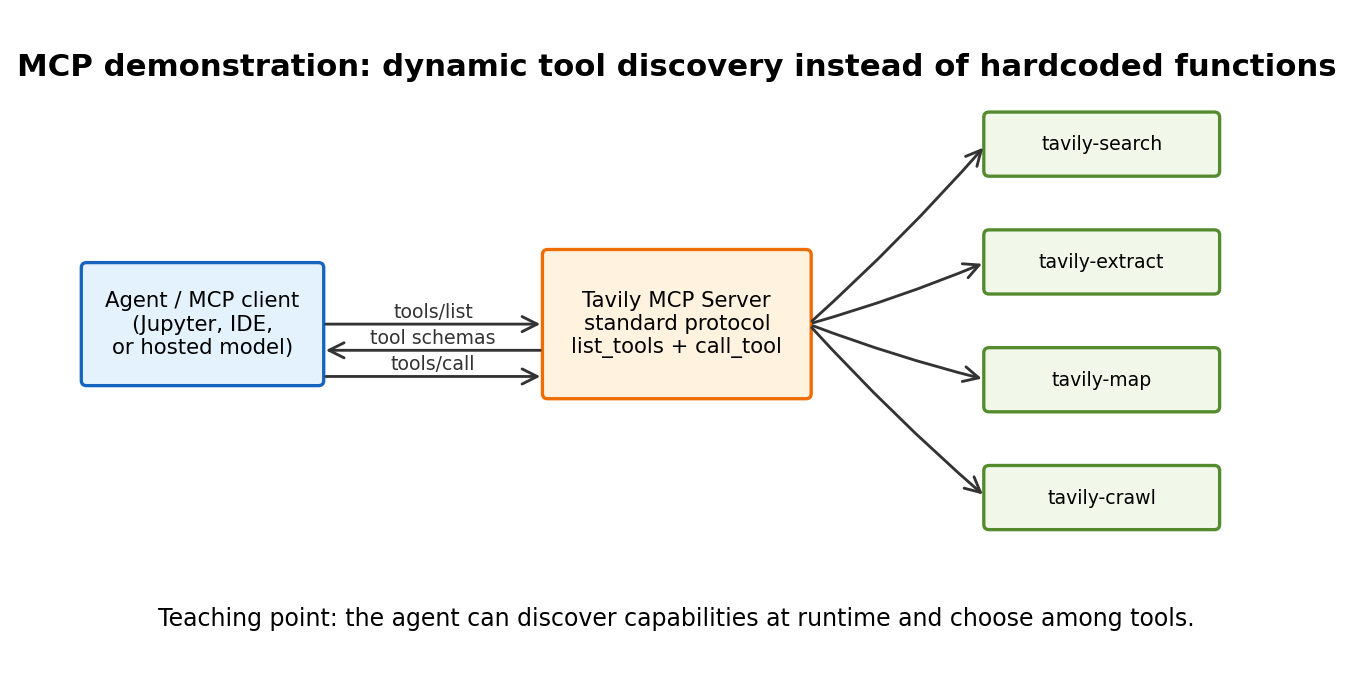</div>

## 1. MCP in plain language

In Class 1, you manually wrote a Tavily tool schema and helper function.

MCP changes the pattern:

1. The agent/client connects to a server.
2. The client asks, “What tools do you expose?”
3. The server returns tool names, descriptions, and input schemas.
4. The agent chooses a tool and sends arguments.
5. The server executes and returns structured results.

This is dynamic tool discovery.

## 2. List Tavily MCP tools

Requirements:
- No Node.js or local MCP process is required
- remote MCP
- Python package `mcp`
- `TAVILY_API_KEY`

Run the next cell to discover what tools the Tavily MCP server exposes.

In [ ]:
# Discover Tavily tools from the current remote MCP server.
# Colab-friendly: no Node.js, npx, local server, or .env file is required.

from urllib.parse import quote_plus
from mcp import ClientSession
from mcp.client.streamable_http import streamable_http_client

TAVILY_MCP_BASE_URL = "https://mcp.tavily.com/mcp/"


def tavily_mcp_url() -> str:
    api_key = load_secret("TAVILY_API_KEY")
    if api_key:
        return f"{TAVILY_MCP_BASE_URL}?tavilyApiKey={quote_plus(api_key)}"
    return TAVILY_MCP_BASE_URL


async def list_tavily_mcp_tools():
    async with streamable_http_client(tavily_mcp_url()) as (read_stream, write_stream, _):
        async with ClientSession(read_stream, write_stream) as session:
            await session.initialize()
            response = await session.list_tools()
            for tool in response.tools:
                print(f"\nTOOL: {tool.name}")
                print(f"Description: {tool.description}")
                print("Input schema:")
                print(json.dumps(tool.inputSchema, indent=2)[:1800])
            return response.tools


mcp_tools = await list_tavily_mcp_tools()
print("\nDiscovered tool names:", [tool.name for tool in mcp_tools])

Caught ExceptionGroup during Tavily MCP tool discovery: unhandled errors in a TaskGroup (1 sub-exception)
  Sub-exception 1: HTTPStatusError: Client error '401 Unauthorized' for url 'https://mcp.tavily.com/mcp/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401


ExceptionGroup: unhandled errors in a TaskGroup (1 sub-exception)

### Reflection: discovered tools

Fill this after running the MCP list-tools cell.

In [ ]:
mcp_reflection = {
    "tools_seen": [],
    "most_obvious_search_tool": "",
    "tool_for_extracting_a_known_url": "",
    "schema_field_that_limits_behavior": "",
}
mcp_reflection

## 3. Call a discovered MCP tool

The next cell calls a Tavily MCP tool.  
If the tool name differs in your discovered list, update `tool_name`.

In [ ]:
# Call a Tavily MCP tool discovered at runtime.

async def call_tavily_mcp_tool(tool_name: str, arguments: Dict[str, Any]):
    t0 = time.perf_counter()
    async with streamable_http_client(tavily_mcp_url()) as (read_stream, write_stream, _):
        async with ClientSession(read_stream, write_stream) as session:
            await session.initialize()
            result = await session.call_tool(tool_name, arguments=arguments)
    return result, round(time.perf_counter() - t0, 3)


# Tool names can change; select from the discovered list rather than assuming.
search_tool = next((tool.name for tool in mcp_tools if "search" in tool.name.lower()), mcp_tools[0].name)
result, elapsed_s = await call_tavily_mcp_tool(
    search_tool,
    {"query": "Model Context Protocol remote tool discovery Tavily", "max_results": 3},
)
print("MCP call elapsed seconds:", elapsed_s)
print(result)

## 4. Route user intent to a discovered tool

A router chooses the best tool for the user’s intent.  
In production, use embeddings from your Week 3/RAG module. Here we use a lightweight token-overlap router so you can see the logic without another API key.

In [ ]:
# Dynamic tool router over discovered MCP tools
# This simple router uses token overlap so it can run without another embedding API.
# In production, replace `simple_embed` with your Week 3 embedding model and cosine similarity.

def tokenize(text: str) -> List[str]:
    return re.findall(r"[a-z0-9]+", (text or "").lower())

def simple_embed(text: str) -> Counter:
    return Counter(tokenize(text))

def cosine_counter(a: Counter, b: Counter) -> float:
    if not a or not b:
        return 0.0
    common = set(a) & set(b)
    dot = sum(a[k] * b[k] for k in common)
    norm_a = math.sqrt(sum(v*v for v in a.values()))
    norm_b = math.sqrt(sum(v*v for v in b.values()))
    return dot / (norm_a * norm_b) if norm_a and norm_b else 0.0

def choose_tool_by_description(user_query: str, tools) -> Tuple[str, List[Tuple[str, float]]]:
    qv = simple_embed(user_query)
    scores = []
    for t in tools:
        desc = f"{t.name} {t.description} {json.dumps(t.inputSchema)}"
        score = cosine_counter(qv, simple_embed(desc))
        scores.append((t.name, round(score, 4)))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[0][0], scores

candidate_intents = [
    "Find recent web information about MCP adoption",
    "Extract clean content from this URL",
    "Map all pages on a documentation website",
    "Crawl a site to discover linked pages",
]

for intent in candidate_intents:
    best, scores = choose_tool_by_description(intent, mcp_tools)
    print("\nUser intent:", intent)
    print("Chosen tool:", best)
    print("Scores:", scores)

### Try it

Add two new intents and observe the selected tool.

In [ ]:
my_intents = [
    "Search current information about AI agents in finance",
    "Extract the article text from a URL so an LLM can summarize it",
]

for intent in my_intents:
    best, scores = choose_tool_by_description(intent, mcp_tools)
    print("\nUser intent:", intent)
    print("Chosen tool:", best)
    print("Scores:", scores)

## 5. Observability

Live APIs and MCP tools introduce real operational issues:
- Latency variability.
- Rate limits.
- Authentication errors.
- Empty/irrelevant results.
- Tool server startup issues.
- Different tool names/schemas across versions.

Log each tool call.

In [ ]:
# Create a logging table for tool runs.
conn = sqlite3.connect("agent_tool_runs.sqlite")
conn.execute("""
CREATE TABLE IF NOT EXISTS tool_runs (
    run_id TEXT,
    step TEXT,
    tool_name TEXT,
    query TEXT,
    latency_s REAL,
    result_count INTEGER,
    success INTEGER,
    request_id TEXT,
    error TEXT,
    created_at TEXT
)
""")
conn.commit()

def log_event(conn, *, run_id, step, tool_name, query, latency_s=None, result_count=None, success=True, request_id=None, error=None):
    conn.execute(
        "INSERT INTO tool_runs VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, datetime('now'))",
        (run_id, step, tool_name, query, latency_s, result_count, int(success), request_id, error)
    )
    conn.commit()

print("Logging table ready.")

## 6. Capstone 2 — Enhanced RAG + live web fallback

The agent should:
1. Try the local/RAG knowledge base first.
2. Score confidence.
3. Use live Tavily web search when confidence is low.
4. Send noisy web results through reviewer/ranking logic.
5. Synthesize a final answer.
6. Log all tool calls.

In [ ]:
# Minimal enhanced-agent skeleton.
# Replace LOCAL_KB with Pinecone or your existing RAG retriever.

memory = deque(maxlen=6)

LOCAL_KB = {
    "what is mcp": "MCP is a protocol pattern for tool discovery and invocation.",
    "what is a tool": "A tool is a callable capability exposed to an agent via a schema and implementation.",
}

def retrieve_from_local_kb(question: str) -> Tuple[str, float]:
    q = question.lower()
    best_key = None
    best_score = 0.0
    for k in LOCAL_KB:
        score = cosine_counter(simple_embed(q), simple_embed(k))
        if score > best_score:
            best_key = k
            best_score = score
    if best_key and best_score >= 0.4:
        return LOCAL_KB[best_key], min(0.95, best_score)
    return "", best_score

def synthesize_answer_without_llm(question: str, rag_answer: str, web_items: List[Dict[str, Any]]) -> str:
    source_lines = "\n".join([f"- {x['title']} ({x['domain']}): {x['url']}" for x in web_items[:3]])
    return f"""Question: {question}

RAG answer:
{rag_answer or 'No confident local answer.'}

Live web evidence:
{source_lines}

Next step:
Use a Reviewer LLM/final synthesis model to convert this evidence into a polished response.
"""

def enhanced_agent(question: str, threshold: float = 0.60) -> str:
    memory.append(("user", question))
    rag_answer, confidence = retrieve_from_local_kb(question)
    print(f"RAG confidence: {confidence:.2f}")

    web_items = []
    if confidence < threshold:
        print("Low confidence: invoking live Tavily web search...")
        r = tavily_search_live(question, topic="general", max_results=5, search_depth="basic", include_answer=False)
        web_items = deduplicate_results([r])
        print(f"Web fallback returned {len(web_items)} unique items in {r.get('_local_wall_clock_s')}s")

    answer = synthesize_answer_without_llm(question, rag_answer, web_items)
    memory.append(("assistant", answer))
    return answer

print(enhanced_agent("What are recent examples of MCP tool discovery for agents?"))

### Advanced: connect remote MCP tools to a free LLM provider

This cell lets Groq or OpenRouter choose among tools discovered from Tavily’s remote MCP server. Tavily works keylessly; a free Tavily key is optional.

In [ ]:
# Provider-neutral MCP + LLM bridge using Groq or OpenRouter.
# The LLM selects a discovered MCP tool; Python executes it; the LLM then synthesizes the answer.

def mcp_result_to_text(result) -> str:
    chunks = []
    for block in getattr(result, "content", []) or []:
        text = getattr(block, "text", None)
        if text:
            chunks.append(text)
        elif hasattr(block, "model_dump"):
            chunks.append(json.dumps(block.model_dump(), default=str))
        else:
            chunks.append(str(block))
    if not chunks and hasattr(result, "model_dump"):
        return json.dumps(result.model_dump(), default=str)
    return "\n".join(chunks)


def mcp_tools_for_llm(tools) -> list[dict]:
    return [
        {
            "type": "function",
            "function": {
                "name": tool.name,
                "description": tool.description or "MCP tool",
                "parameters": tool.inputSchema,
            },
        }
        for tool in tools
    ]


async def ask_llm_with_tavily_mcp(question: str) -> str:
    client, model = get_llm_client_and_model()
    tool_schemas = mcp_tools_for_llm(mcp_tools)
    messages = [
        {
            "role": "system",
            "content": "Use the available MCP tools when current web evidence is needed. Cite source URLs returned by tools.",
        },
        {"role": "user", "content": question},
    ]

    try:
        first = client.chat.completions.create(
            model=model,
            messages=messages,
            tools=tool_schemas,
            tool_choice="auto",
            temperature=0.1,
        )
        assistant_message = first.choices[0].message
        messages.append(assistant_message.model_dump(exclude_none=True))

        if not assistant_message.tool_calls:
            return assistant_message.content or "The model chose not to call an MCP tool."

        for tool_call in assistant_message.tool_calls:
            arguments = json.loads(tool_call.function.arguments or "{}")
            tool_result, _ = await call_tavily_mcp_tool(tool_call.function.name, arguments)
            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": mcp_result_to_text(tool_result),
            })
    except Exception as tool_call_error:
        # Some free-routed models may not expose tool calling. Fall back to the
        # notebook's deterministic schema router, then ask the LLM to synthesize.
        selected_tool, _ = choose_tool_by_description(question, mcp_tools)
        selected_schema = next(t.inputSchema for t in mcp_tools if t.name == selected_tool)
        properties = selected_schema.get("properties", {})
        arguments = {"query": question} if "query" in properties else {}
        tool_result, _ = await call_tavily_mcp_tool(selected_tool, arguments)
        messages.append({
            "role": "user",
            "content": (
                f"Tool calling was unavailable for the selected free model ({type(tool_call_error).__name__}). "
                f"Python selected MCP tool '{selected_tool}'. Use this tool result to answer with source links:\n"
                + mcp_result_to_text(tool_result)
            ),
        })

    final = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0.2,
    )
    return final.choices[0].message.content or ""


answer = await ask_llm_with_tavily_mcp(
    "Search for recent examples of MCP tool discovery and summarize four evidence-backed points with source links."
)
print(answer)

In [ ]:
CLASS_2_QUIZ = [
    {
        "question": "What is the main advantage of MCP over hardcoded Python tool dictionaries?",
        "options": ["MCP removes the need for API keys", "MCP allows tools to be discovered and called through a standard protocol", "MCP makes all tools free", "MCP prevents latency"],
        "answer": "MCP allows tools to be discovered and called through a standard protocol",
        "explanation": "An MCP client can ask the server for tools and schemas at runtime."
    },
    {
        "question": "Which Tavily MCP behavior best demonstrates tool discovery?",
        "options": ["The server returns a list of tools and input schemas", "The API always returns the same article", "The LLM memorizes the web", "The notebook hardcodes all functions"],
        "answer": "The server returns a list of tools and input schemas",
        "explanation": "Listing tools is the moment students see dynamic capability discovery."
    },
    {
        "question": "Why log request IDs, latency, and success/failure for each tool call?",
        "options": ["Only for decoration", "To reproduce failures and diagnose performance", "To make prompts longer", "To hide API usage"],
        "answer": "To reproduce failures and diagnose performance",
        "explanation": "Production agents must be observable; otherwise failures become impossible to debug."
    },
    {
        "question": "What should an agent do when search results are low-confidence or noisy?",
        "options": ["Pretend confidence is high", "Use reviewer/ranking logic, broaden/refine queries, or trigger fallback", "Email all raw results", "Disable validation"],
        "answer": "Use reviewer/ranking logic, broaden/refine queries, or trigger fallback",
        "explanation": "The agent should make uncertainty visible and use explicit recovery strategies."
    },
]
run_quiz(CLASS_2_QUIZ, title="Class 2 knowledge check")

# Final reflection

Answer these before the next class:

1. What is the difference between Tavily’s Python SDK and Tavily MCP?
2. Why did live search make the reviewer LLM more important?
3. What did you learn from measuring latency?
4. What tool-call fields would you log in production?
5. When should an agent fall back from RAG to web search?
6. What is one risk of allowing a tool to create side effects?

In [ ]:
final_reflection = {
    "sdk_vs_mcp": "",
    "reviewer_llm_importance": "",
    "latency_learning": "",
    "production_log_fields": "",
    "rag_to_web_fallback_rule": "",
    "side_effect_risk": "",
}
final_reflection

# Appendix — safe real-world integration checklist

Before connecting live systems:
- Use test accounts and non-sensitive data.
- Store API keys in environment variables or secret managers.
- Add rate limiting.
- Add retries with exponential backoff.
- Validate tool arguments before execution.
- Validate tool outputs before passing downstream.
- Log request IDs, latency, and errors.
- Require confirmation for irreversible side effects.
- Make uncertainty visible to the user.